# Capability Harvesting

## Preparation

In [1]:
import json
import re

from typing import Optional
from collections import Counter
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_selection import mutual_info_classif

In [2]:
# pd.set_option('display.max_rows', None)

In [3]:
def prepare_dataset(datasets):
    tidy_dfs = []
    
    for dataset in datasets:
        wide_df = (
            pd
                .read_csv(dataset)
                .set_index("Capability")
                .T
                .reset_index(names="endpoint")
        )
    
        tidy_df = wide_df.melt(
            id_vars="endpoint",
            var_name="name",
            value_name="value"
        )
    
        tidy_dfs.append(tidy_df)
    
    df = pd.concat(tidy_dfs, ignore_index=True)
    df = df.dropna(subset=["value"])
    df = df.drop_duplicates(subset=["endpoint", "name"])
    df[["handle", "device_id"]] = (
        df["endpoint"]
            .copy()
            .str.split("#", n=1, expand=True)
    )
    df["name"] = df["name"].str.removeprefix("client-data.")

    return df

In [4]:
dataset_our = ["harvested_devices.csv"]
dataset_vos = ["harvested_visionpro.csv"]

df = prepare_dataset(dataset_our + dataset_vos)

In [5]:
df

,endpoint,name,value,handle,device_id
0,mailto:owner-a@example.org#0,ec-version,1.0,mailto:owner-a@example.org,0
1,mailto:owner-a@example.org#1,ec-version,1.0,mailto:owner-a@example.org,1
2,mailto:owner-a@example.org#2,ec-version,1.0,mailto:owner-a@example.org,2
3,mailto:owner-b@example.org#0,ec-version,1.0,mailto:owner-b@example.org,0
4,mailto:owner-c@example.org#0,ec-version,1.0,mailto:owner-c@example.org,0
...,...,...,...,...,...
1009,mailto:owner-d@example.org#0,session-token-refresh-seconds,25200,mailto:owner-d@example.org,0
1010,mailto:owner-d@example.org#1,session-token-refresh-seconds,25200,mailto:owner-d@example.org,1
1011,mailto:owner-d@example.org#2,session-token-refresh-seconds,25200,mailto:owner-d@example.org,2
1012,mailto:owner-d@example.org#3,session-token-refresh-seconds,25200,mailto:owner-d@example.org,3


Filter for the Vision Pro from the participant

In [6]:
df = df[~((df["endpoint"].str.startswith("mailto:owner-d@example.org")) & (df["endpoint"] != "mailto:owner-d@example.org#3"))].reset_index(drop=True)

## Analysis on harvested devices

In [7]:
df["device_id"].unique()

array(['0', '1', '2', '3'], dtype=object)

In [8]:
df.groupby("handle")["device_id"].nunique().agg(
    min_devices="min",
    max_devices="max",
    avg_devices="mean",
)

min_devices    1.00
max_devices    4.00
avg_devices    2.25
Name: device_id, dtype: float64

In [9]:
df.groupby("handle")["device_id"].nunique().value_counts()

device_id
1    2
3    1
4    1
Name: count, dtype: int64

<Axes: >

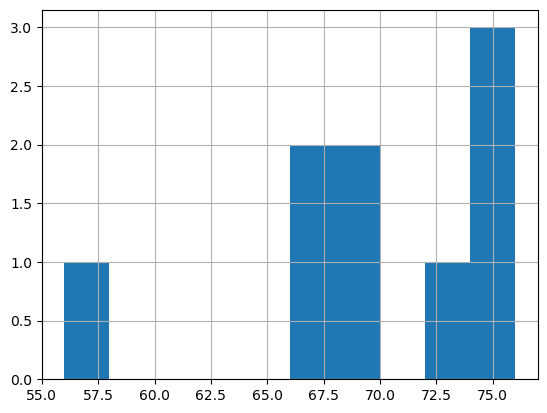

In [10]:
(
    df
        .groupby(["handle", "device_id"])["name"]
        .nunique()
        .rename("cap_count")
        .hist()
)

In [11]:
n_endpoints_total = (
    df[["handle", "device_id"]]
        .drop_duplicates()
        .shape[0]
)

In [12]:
cap_count = (
    df
        .drop_duplicates(["handle", "device_id", "name"])
        .groupby("name")
        .size()
        .rename("n_endpoints")
        .reset_index()
        .sort_values("n_endpoints", ascending=False)
)
cap_count

,name,n_endpoints
0,ec-version,9
1,kt-version,9
2,nicknames-version,9
3,optionally-receive-typing-indicators,9
4,prefers-sdr,9
...,...,...
61,supports-recovery-contact-upsell,5
68,supports-significant-app-update,4
57,supports-queue-one-read-receipts,3
71,supports-stewie,3


<Axes: >

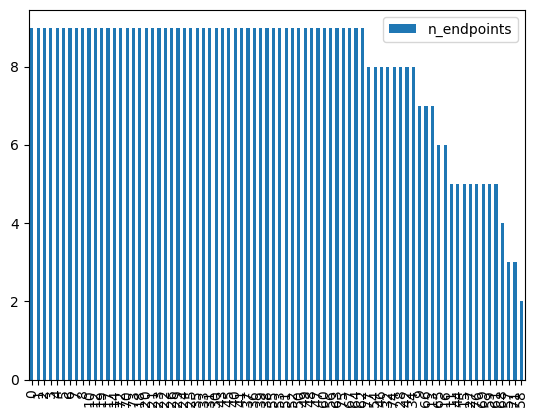

In [13]:
cap_count.plot(kind="bar")

In [14]:
cap_count["share"] = cap_count["n_endpoints"] / n_endpoints_total
# cap_count.to_csv("cap_count.csv")
cap_count

,name,n_endpoints,share
0,ec-version,9,1.000000
1,kt-version,9,1.000000
2,nicknames-version,9,1.000000
3,optionally-receive-typing-indicators,9,1.000000
4,prefers-sdr,9,1.000000
...,...,...,...
61,supports-recovery-contact-upsell,5,0.555556
68,supports-significant-app-update,4,0.444444
57,supports-queue-one-read-receipts,3,0.333333
71,supports-stewie,3,0.333333


In [15]:
def classify_n_endpoints(n):
    if n == n_endpoints_total:
        return "universal"
    elif n > 0.5 * n_endpoints_total:
        return "common"
    elif n > 10:
        return "rare"
    else:
        return "very_rare"

cap_count["class"] = (cap_count["n_endpoints"]
    .apply(classify_n_endpoints))

In [16]:
cap_count

,name,n_endpoints,share,class
0,ec-version,9,1.000000,universal
1,kt-version,9,1.000000,universal
2,nicknames-version,9,1.000000,universal
3,optionally-receive-typing-indicators,9,1.000000,universal
4,prefers-sdr,9,1.000000,universal
...,...,...,...,...
61,supports-recovery-contact-upsell,5,0.555556,common
68,supports-significant-app-update,4,0.444444,very_rare
57,supports-queue-one-read-receipts,3,0.333333,very_rare
71,supports-stewie,3,0.333333,very_rare


## Import First Seen / Last Seen

In [17]:
df_fs = pd.read_csv("output/capability_first_last_seen.csv")
df_fs = df_fs[["device_type", "name", "first_os_version"]]

In [18]:
def parse_os_version(v):
    """
    '26.2' -> (26, 2)
    """
    return tuple(int(p) for p in v.split("."))

def device_type_from_model(model: str):
    if model.startswith("iPhone"):
        return "iPhone"
    if model.startswith("iPad"):
        return "iPad"
    if model.startswith("Watch"):
        return "Watch"
    if "Mac" in model:
        return "Mac"
    if "Vision" in model:
        return "VisionPro"
    raise ValueError(f"Unknown Device Type from model: {model}")

df_fs["first_os_version_key"] = df_fs["first_os_version"].apply(parse_os_version)

In [19]:
df_fs

,device_type,name,first_os_version,first_os_version_key
0,Mac,device-key-signature,13.0,"(13, 0)"
1,Mac,ec-version,11.0.1,"(11, 0, 1)"
2,Mac,is-c2k-equipment,11.0.1,"(11, 0, 1)"
3,Mac,is-green-tea,12.0.1,"(12, 0, 1)"
4,Mac,is-web-client,13.0,"(13, 0)"
...,...,...,...,...
477,iPhone,supports-update-attachments-v1,12.0,"(12, 0)"
478,iPhone,supports-uriless-membership-updates,26.0,"(26, 0)"
479,iPhone,supports-user-driven-call-activation,18.4,"(18, 4)"
480,iPhone,supports-uwb,15.0,"(15, 0)"


In [20]:
def infer_endpoint_version(group):
    return (
        group[["name"]]
            .dropna()
            .drop_duplicates()
            .merge(
                df_fs[["name", "device_type", "first_os_version_key"]],
                on="name",
                how="left"
            )
            .groupby("device_type", as_index=False)["first_os_version_key"]
            .max()
            .set_index("device_type")["first_os_version_key"]
            .rename(lambda d: f"os_candidate_{d}")
            .to_dict()
    )

In [21]:
version_classifier = (
    df
        .drop_duplicates(["handle", "device_id", "name"])
        .groupby(["handle", "device_id"], as_index=False)
        .apply(lambda g: pd.Series(infer_endpoint_version(g)), include_groups=False)
)
version_classifier

,handle,device_id,os_candidate_Mac,os_candidate_VisionPro,os_candidate_iPad,os_candidate_iPhone
0,mailto:owner-a@example.org,0,"(26, 3)","(26, 3)","(26, 2)","(26, 2)"
1,mailto:owner-a@example.org,1,"(26, 0)","(26, 0)","(26, 0)","(26, 1)"
2,mailto:owner-a@example.org,2,"(26, 3)","(26, 3)","(26, 2)","(26, 1)"
3,mailto:owner-b@example.org,0,"(26, 3)","(26, 3)","(26, 2)","(26, 2)"
4,mailto:owner-c@example.org,0,"(15, 6)","(26, 0)","(18, 7, 1)","(18, 6)"
5,mailto:owner-c@example.org,1,"(26, 3)","(26, 3)","(26, 2)","(26, 2)"
6,mailto:owner-c@example.org,2,"(26, 3)","(26, 3)","(26, 2)","(26, 2)"
7,mailto:owner-c@example.org,3,"(26, 3)","(26, 3)","(26, 2)","(26, 2)"
8,mailto:owner-d@example.org,3,"(26, 0)","(26, 0)","(26, 0)","(26, 0)"


## Classifiers

In [22]:
all_caps_versions = pd.read_csv("output/firmware_capabilities_by_os.csv")
all_caps_versions["typed_value"] = all_caps_versions["typed_value"].replace(
    {"True": True, "False": False}
)
all_caps_versions

,device_type,os_version_key,name,typed_value
0,Mac,"(11, 0, 1)",ec-version,1.0
1,Mac,"(11, 0, 1)",is-c2k-equipment,False
2,Mac,"(11, 0, 1)",kt-version,4.0
3,Mac,"(11, 0, 1)",nicknames-version,NaN
4,Mac,"(11, 0, 1)",optionally-receive-typing-indicators,NaN
...,...,...,...,...
5810,iPhone,"(26, 3)",supports-update-attachments-v1,NaN
5811,iPhone,"(26, 3)",supports-uriless-membership-updates,NaN
5812,iPhone,"(26, 3)",supports-user-driven-call-activation,NaN
5813,iPhone,"(26, 3)",supports-uwb,True


In [23]:
df["typed_value"] = df["value"].replace(
    {"T": True, "F": False}
)

## Device Classification

In [24]:
dev_df = pd.read_csv("output/firmware_capabilities_by_device.csv")
dev_df["os_version"] = dev_df["os_version"].apply(parse_os_version)
dev_df["typed_value"] = dev_df["typed_value"].replace({
    "True": True, "False": False, "true": True, "false": False
})
dev_df["source"] = "static"
dev_df["verified"] = False

In [25]:
def dev_caps_ge_os(dev_df, lower_bound: tuple, device_type: Optional[str]):
    mask = dev_df["os_version"] >= lower_bound

    if device_type:
        mask = mask & (dev_df["device_type"] == device_type)
    
    return dev_df[mask]

In [26]:
dev_caps_ge_os(dev_df, (26,0), None)

,device_type,device_model,os_version,name,typed_value,source,verified
57,iPhone,"iPhone12,3","(26, 3)",show-peer-errors,NaN,static,False
58,iPhone,"iPhone12,5","(26, 3)",show-peer-errors,NaN,static,False
59,iPhone,"iPhone12,3","(26, 3)",is-c2k-equipment,NaN,static,False
60,iPhone,"iPhone12,5","(26, 3)",is-c2k-equipment,NaN,static,False
61,iPhone,"iPhone12,3","(26, 3)",supports-inline-attachments,NaN,static,False
...,...,...,...,...,...,...,...
13283,iPhone,"iPhone14,7","(26, 3)",supports-legacy-contact-invites-v2,NaN,static,False
13284,iPhone,"iPhone14,7","(26, 3)",supports-legacy-contact-invites-v3,NaN,static,False
13285,iPhone,"iPhone14,7","(26, 3)",supports-calls-25,NaN,static,False
13286,iPhone,"iPhone14,7","(26, 3)",supports-introductions-v1,NaN,static,False


In [27]:
def dev_caps_for_device(dev_df, device_model: str, os_version: tuple):
    mask = (dev_df["os_version"] == os_version) & (dev_df["device_model"] == device_model)
    
    return dev_df[mask]

In [28]:
dev_caps_for_device(dev_df, "iPhone14,7", (26,3)).query("name == 'supports-heif'")["typed_value"].iloc[0]

True

In [29]:
def label_cap(row):
    name = row["name"]
    value = row["typed_value"]
    
    if pd.isna(value):
        return f"VALUE::{name}::NA"
        
    if value == False:
        return f"VALUE::{name}::false"
    else:
        return f"VALUE::{name}::{value}"

def refresh_labels(df):
    df["label"] = df.apply(label_cap, axis=1)
    return df

In [30]:
refresh_labels(dev_df)

,device_type,device_model,os_version,name,typed_value,source,verified,label
0,iPhone,"iPhone14,4","(15, 5)",show-peer-errors,NaN,static,False,VALUE::show-peer-errors::NA
1,iPhone,"iPhone14,4","(15, 5)",is-c2k-equipment,NaN,static,False,VALUE::is-c2k-equipment::NA
2,iPhone,"iPhone14,4","(15, 5)",supports-inline-attachments,NaN,static,False,VALUE::supports-inline-attachments::NA
3,iPhone,"iPhone14,4","(15, 5)",supports-keep-receipts,NaN,static,False,VALUE::supports-keep-receipts::NA
4,iPhone,"iPhone14,4","(15, 5)",supports-location-sharing,NaN,static,False,VALUE::supports-location-sharing::NA
...,...,...,...,...,...,...,...,...
13283,iPhone,"iPhone14,7","(26, 3)",supports-legacy-contact-invites-v2,NaN,static,False,VALUE::supports-legacy-contact-invites-v2::NA
13284,iPhone,"iPhone14,7","(26, 3)",supports-legacy-contact-invites-v3,NaN,static,False,VALUE::supports-legacy-contact-invites-v3::NA
13285,iPhone,"iPhone14,7","(26, 3)",supports-calls-25,NaN,static,False,VALUE::supports-calls-25::NA
13286,iPhone,"iPhone14,7","(26, 3)",supports-introductions-v1,NaN,static,False,VALUE::supports-introductions-v1::NA


In [31]:
def get_caps_for_probe(handle: str, device_id: str):
    mask = (df["handle"] == handle) & (df["device_id"] == device_id)
    return df[mask][["handle", "device_id", "name", "value", "typed_value"]]

In [32]:
def remove_ignored_caps(df):
    return df[df["name"] != "session-token-refresh-seconds"]

In [33]:
def learn_v1(df_dev_caps, df_probe_caps, device_model, os_version):
    df_dev_caps_row = dev_caps_for_device(df_dev_caps, device_model, os_version)

    
    to_create = []

    for idx, cap in df_probe_caps.iterrows():
        # print(cap["name"], cap["typed_value"])

        if cap["name"] in ("session-token-refresh-seconds",):
            continue

        row = df_dev_caps_row[df_dev_caps_row["name"] == cap["name"]]

        probe_values = {
            "typed_value": cap["typed_value"],
            "verified": True
        }

        
        if row.shape[0] > 0:
            # existing cap entry
            entry = row.iloc[0]

            # Conflicts check
            new_val = cap["typed_value"]
            existing_val = entry["typed_value"]
            if (new_val != existing_val) and (entry["source"] == "static") and not (pd.isna(existing_val)):
                print(
                    f"Warning! Overriding static value for {cap["name"]}:",
                    f"static={entry["typed_value"]}, probe={cap["typed_value"]}"
                )
                probe_values["source"] = "probe"

            # Update
            df_dev_caps.loc[row.index[0], list(probe_values.keys())] = list(probe_values.values())
        else:
            print(f"Info: No existing entry for {cap["name"]}, creating...")
            to_create.append({
                "device_model": device_model,
                "os_version": os_version,
                "name": cap["name"],
                "source": "probe"} | probe_values)

    result = df_dev_caps
    if to_create:
        pd_new = pd.DataFrame(to_create)
        pd_new["device_type"] = pd_new["device_model"].map(device_type_from_model)
        result = pd.concat([df_dev_caps, pd_new], ignore_index=True)

    return result

In [34]:
dev_df = learn_v1(dev_df, get_caps_for_probe("mailto:owner-c@example.org", "0"), "UniversalMac", (15, 7, 3))
dev_df = learn_v1(dev_df, get_caps_for_probe("mailto:owner-c@example.org", "1"), "iPad_Spring_2022", (26, 2))
dev_df = learn_v1(dev_df, get_caps_for_probe("mailto:owner-c@example.org", "2"), "Watch7,1", (26, 2))
dev_df = learn_v1(dev_df, get_caps_for_probe("mailto:owner-c@example.org", "3"), "iPhone17,1", (26, 2))
dev_df = learn_v1(dev_df, get_caps_for_probe("mailto:owner-a@example.org", "0"), "iPhone18,1", (26, 2))
dev_df = learn_v1(dev_df, get_caps_for_probe("mailto:owner-a@example.org", "1"), "Watch8,1", (26, 1))
dev_df = learn_v1(dev_df, get_caps_for_probe("mailto:owner-a@example.org", "2"), "UniversalMac", (26, 2))
dev_df = learn_v1(dev_df, get_caps_for_probe("mailto:owner-b@example.org", "0"), "iPhone17,1", (26, 2))
dev_df = learn_v1(dev_df, get_caps_for_probe("mailto:owner-d@example.org", "3"), "VisionPro", (26, 0))
refresh_labels(dev_df)

Info: No existing entry for ec-version, creating...
Info: No existing entry for kt-version, creating...
Info: No existing entry for nicknames-version, creating...
Info: No existing entry for optionally-receive-typing-indicators, creating...
Info: No existing entry for prefers-sdr, creating...
Info: No existing entry for public-message-identity-ngm-version, creating...
Info: No existing entry for public-message-identity-version, creating...
Info: No existing entry for sender-key-message-version, creating...
Info: No existing entry for supports-ack-v1, creating...
Info: No existing entry for supports-animoji-v2, creating...
Info: No existing entry for supports-askto, creating...
Info: No existing entry for supports-audio-messaging-v2, creating...
Info: No existing entry for supports-autoloopvideo-v1, creating...
Info: No existing entry for supports-be-v1, creating...
Info: No existing entry for supports-ca-v1, creating...
Info: No existing entry for supports-certified-delivery-v1, creati

,device_type,device_model,os_version,name,typed_value,source,verified,label
0,iPhone,"iPhone14,4","(15, 5)",show-peer-errors,NaN,static,False,VALUE::show-peer-errors::NA
1,iPhone,"iPhone14,4","(15, 5)",is-c2k-equipment,NaN,static,False,VALUE::is-c2k-equipment::NA
2,iPhone,"iPhone14,4","(15, 5)",supports-inline-attachments,NaN,static,False,VALUE::supports-inline-attachments::NA
3,iPhone,"iPhone14,4","(15, 5)",supports-keep-receipts,NaN,static,False,VALUE::supports-keep-receipts::NA
4,iPhone,"iPhone14,4","(15, 5)",supports-location-sharing,NaN,static,False,VALUE::supports-location-sharing::NA
...,...,...,...,...,...,...,...,...
13756,VisionPro,VisionPro,"(26, 0)",supports-st-v1,True,probe,True,VALUE::supports-st-v1::True
13757,VisionPro,VisionPro,"(26, 0)",supports-stick-moji-backs,True,probe,True,VALUE::supports-stick-moji-backs::True
13758,VisionPro,VisionPro,"(26, 0)",supports-sticker-editing,True,probe,True,VALUE::supports-sticker-editing::True
13759,VisionPro,VisionPro,"(26, 0)",supports-transcript-backgrounds,True,probe,True,VALUE::supports-transcript-backgrounds::True


In [35]:
dev_caps_for_device(dev_df, "iPhone17,1", (26,2)).head()#.to_csv("iPhone17,1_26,2.csv")

,device_type,device_model,os_version,name,typed_value,source,verified,label
13412,iPhone,"iPhone17,1","(26, 2)",ec-version,1.0,probe,True,VALUE::ec-version::1.0
13413,iPhone,"iPhone17,1","(26, 2)",kt-version,5.0,probe,True,VALUE::kt-version::5.0
13414,iPhone,"iPhone17,1","(26, 2)",nicknames-version,1.0,probe,True,VALUE::nicknames-version::1.0
13415,iPhone,"iPhone17,1","(26, 2)",optionally-receive-typing-indicators,True,probe,True,VALUE::optionally-receive-typing-indicators::True
13416,iPhone,"iPhone17,1","(26, 2)",prefers-sdr,False,probe,True,VALUE::prefers-sdr::false


In [36]:
verified_caps = dev_df[dev_df["verified"] == True].reset_index(drop=True)
# verified_caps = dev_df[(dev_df["verified"] == True) | ((dev_df["verified"] == False) & (~dev_df["typed_value"].isna()))].copy().reset_index(drop=True)
# verified_caps = dev_df[~dev_df["typed_value"].isna()].copy().reset_index(drop=True)
# verified_caps = dev_df[dev_df["os_version"] >= (26,0)].copy().reset_index(drop=True)
verified_caps

,device_type,device_model,os_version,name,typed_value,source,verified,label
0,iPad,iPad_Spring_2022,"(26, 2)",show-peer-errors,True,static,True,VALUE::show-peer-errors::True
1,iPad,iPad_Spring_2022,"(26, 2)",supports-inline-attachments,True,static,True,VALUE::supports-inline-attachments::True
2,iPad,iPad_Spring_2022,"(26, 2)",supports-keep-receipts,True,static,True,VALUE::supports-keep-receipts::True
3,iPad,iPad_Spring_2022,"(26, 2)",supports-location-sharing,True,static,True,VALUE::supports-location-sharing::True
4,iPad,iPad_Spring_2022,"(26, 2)",supports-media-v2,True,static,True,VALUE::supports-media-v2::True
...,...,...,...,...,...,...,...,...
537,VisionPro,VisionPro,"(26, 0)",supports-st-v1,True,probe,True,VALUE::supports-st-v1::True
538,VisionPro,VisionPro,"(26, 0)",supports-stick-moji-backs,True,probe,True,VALUE::supports-stick-moji-backs::True
539,VisionPro,VisionPro,"(26, 0)",supports-sticker-editing,True,probe,True,VALUE::supports-sticker-editing::True
540,VisionPro,VisionPro,"(26, 0)",supports-transcript-backgrounds,True,probe,True,VALUE::supports-transcript-backgrounds::True


In [37]:
caps_pivot = (
    verified_caps
        .pivot_table(
            index=["device_type", "device_model", "os_version"],
            columns="name",
            values="typed_value",
            aggfunc="first"
        )
)
caps_pivot

name                                    ec-version kt-version  \
device_type device_model     os_version                         
Mac         UniversalMac     (15, 7, 3)        1.0        5.0   
                             (26, 2)           1.0        5.0   
VisionPro   VisionPro        (26, 0)           1.0        5.0   
Watch       Watch7,1         (26, 2)           1.0        5.0   
            Watch8,1         (26, 1)           1.0        5.0   
iPad        iPad_Spring_2022 (26, 2)           1.0        5.0   
iPhone      iPhone17,1       (26, 2)           1.0        5.0   
            iPhone18,1       (26, 2)           1.0        5.0   

name                                    nicknames-version  \
device_type device_model     os_version                     
Mac         UniversalMac     (15, 7, 3)               1.0   
                             (26, 2)                  1.0   
VisionPro   VisionPro        (26, 0)                  1.0   
Watch       Watch7,1         (26, 2)                  1.0   
            Watch8,1         (26, 1)                  1.0   
iPad        iPad_Spring_2022 (26, 2)                  1.0   
iPhone      iPhone17,1       (26, 2)                  1.0   
            iPhone18,1       (26, 2)                  1.0   

name                                    optionally-receive-typing-indicators  \
device_type device_model     os_version                                        
Mac         UniversalMac     (15, 7, 3)                                 True   
                             (26, 2)                                    True   
VisionPro   VisionPro        (26, 0)                                    True   
Watch       Watch7,1         (26, 2)                                    True   
            Watch8,1         (26, 1)                                    True   
iPad        iPad_Spring_2022 (26, 2)                                    True   
iPhone      iPhone17,1       (26, 2)                                    True   
            iPhone18,1       (26, 2)                                    True   

name                                    prefers-sdr  \
device_type device_model     os_version               
Mac         UniversalMac     (15, 7, 3)       False   
                             (26, 2)          False   
VisionPro   VisionPro        (26, 0)          False   
Watch       Watch7,1         (26, 2)            1.0   
            Watch8,1         (26, 1)            1.0   
iPad        iPad_Spring_2022 (26, 2)          False   
iPhone      iPhone17,1       (26, 2)          False   
            iPhone18,1       (26, 2)          False   

name                                    public-message-identity-ngm-version  \
device_type device_model     os_version                                       
Mac         UniversalMac     (15, 7, 3)                                13.0   
                             (26, 2)                                   13.0   
VisionPro   VisionPro        (26, 0)                                   13.0   
Watch       Watch7,1         (26, 2)                                   13.0   
            Watch8,1         (26, 1)                                   13.0   
iPad        iPad_Spring_2022 (26, 2)                                   13.0   
iPhone      iPhone17,1       (26, 2)                                   13.0   
            iPhone18,1       (26, 2)                                   13.0   

name                                    public-message-identity-version  \
device_type device_model     os_version                                   
Mac         UniversalMac     (15, 7, 3)                             2.0   
                             (26, 2)                                2.0   
VisionPro   VisionPro        (26, 0)                                2.0   
Watch       Watch7,1         (26, 2)                                2.0   
            Watch8,1         (26, 1)                                2.0   
iPad        iPad_Spring_2022 (26, 2)                                2.

<Axes: xlabel='name'>

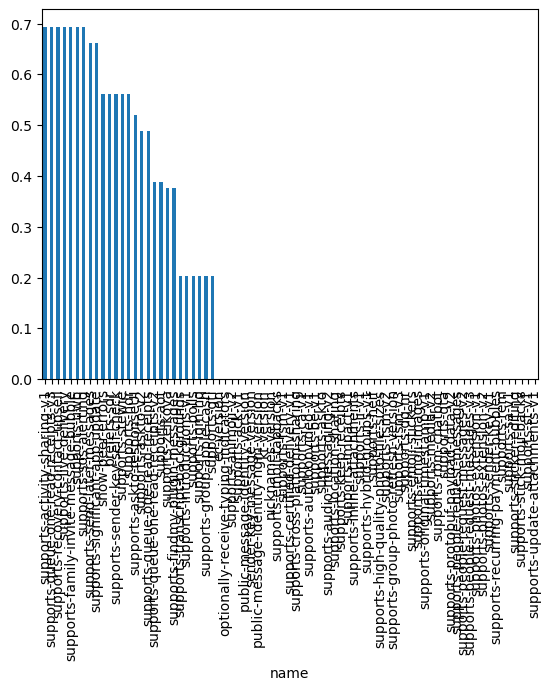

In [38]:
X_raw = caps_pivot.copy()
X_raw = X_raw.dropna(axis=1, how="all")
X_str = X_raw.astype("string").fillna("<<MISSING>>")
X_enc = X_str.apply(lambda s: pd.factorize(s, sort=True)[0]).to_numpy()

y = caps_pivot.index.get_level_values("device_model")
y_enc = pd.factorize(y, sort=True)[0]

mi = mutual_info_classif(
    X_enc,
    y_enc,
    discrete_features=True,
    random_state=0
)

mi_scores = pd.Series(mi, index=X_raw.columns).sort_values(ascending=False)
mi_scores.plot(kind="bar")

In [39]:
top = mi_scores.head(40).index

X_str[top].T

device_type                                    Mac                 VisionPro  \
device_model                          UniversalMac                 VisionPro   
os_version                              (15, 7, 3)      (26, 2)      (26, 0)   
name                                                                           
supports-activity-sharing-v1           <<MISSING>>  <<MISSING>>  <<MISSING>>   
supports-queue-one-read-receipts-v3    <<MISSING>>  <<MISSING>>  <<MISSING>>   
supports-recovery-contact-upsell       <<MISSING>>  <<MISSING>>         True   
supports-live-delivery                 <<MISSING>>  <<MISSING>>         True   
supports-family-invite-message-bubble  <<MISSING>>  <<MISSING>>         True   
supports-uwb                           <<MISSING>>  <<MISSING>>  <<MISSING>>   
supports-sos-alerting                  <<MISSING>>  <<MISSING>>  <<MISSING>>   
supports-send-later-messages                  True         True  <<MISSING>>   
supports-significant-app-update        <<MISSING>>  <<MISSING>>  <<MISSING>>   
show-peer-errors                       <<MISSING>>  <<MISSING>>         True   
prefers-sdr                                  False        False        False   
supports-sender-key-self-check         <<MISSING>>  <<MISSING>>         True   
supports-stewie                        <<MISSING>>  <<MISSING>>  <<MISSING>>   
supports-hdr                                  True         True         True   
supports-askto-responseUI              <<MISSING>>         True  <<MISSING>>   
supports-askto-v2                      <<MISSING>>         True         True   
supports-queue-one-read-receipts       <<MISSING>>         True         True   
supports-queue-one-read-receipts-v2    <<MISSING>>         True  <<MISSING>>   
supports-aot                           <<MISSING>>         True  <<MISSING>>   
supports-zelkova                              True         True  <<MISSING>>   
supports-findmy-plugin-messages               True         True  <<MISSING>>   
supports-transcript-backgrounds        <<MISSING>>         True         True   
supports-introductions-v1              <<MISSING>>         True         True   
supports-polls                         <<MISSING>>         True         True   
supports-lqm-hq                        <<MISSING>>         True         True   
supports-group-apple-cash              <<MISSING>>         True         True   
supports-gti                           <<MISSING>>         True         True   
ec-version                                     1.0          1.0          1.0   
optionally-receive-typing-indicators          True         True         True   
supports-animoji-v2                           True         True         True   
supports-ack-v1                               True         True         True   
public-message-identity-version                2.0          2.0          2.0   
sender-key-message-version                     1.0          1.0          1.0   
public-message-identity-ngm-version           13.0         13.0         13.0   
kt-version                                     5.0          5.0          5.0   
nicknames-version                              1.0          1.0          1.0   
supports-emoji-tapbacks                       True         True         True   
supports-fsm-v1                               True         True         True   
supports-certified-delivery-v1                True         True         True   
supports-cross-platform-sharing               True         True         True   

device_type                                  Watch               \
device_model                              Watch7,1     Watch8,1   
os_version                                 (26, 2)      (26, 1)   
name                                                              
supports-activity-sharing-v1                  True         True   
supports-queue-one-read-receipts-v3           True  <<MISSING>>   
supports-recovery-contact-upsell       <<MISSING>>  <<MISSING>>   
supports-l

In [40]:
varying = X_str.nunique(dropna=False) > 1

X_raw2 = X_raw.loc[:, varying]
X_str2 = X_str.loc[:, varying]

In [41]:
X_enc2 = X_str2.apply(lambda s: pd.factorize(s, sort=True)[0]).to_numpy()

# y = caps_pivot.index.get_level_values("device_model")
# y_enc = pd.factorize(y, sort=True)[0]

mi2 = mutual_info_classif(
    X_enc2,
    y_enc,
    discrete_features=True,
    random_state=0
)

mi_scores2 = pd.Series(mi2, index=X_raw2.columns).sort_values(ascending=False)
mi_scores2

name
supports-activity-sharing-v1             0.693147
supports-family-invite-message-bubble    0.693147
supports-live-delivery                   0.693147
supports-sos-alerting                    0.693147
supports-queue-one-read-receipts-v3      0.693147
supports-recovery-contact-upsell         0.693147
supports-uwb                             0.693147
supports-significant-app-update          0.661563
supports-send-later-messages             0.661563
show-peer-errors                         0.562335
prefers-sdr                              0.562335
supports-stewie                          0.562335
supports-sender-key-self-check           0.562335
supports-hdr                             0.562335
supports-askto-responseUI                0.519860
supports-askto-v2                        0.488276
supports-queue-one-read-receipts         0.488276
supports-queue-one-read-receipts-v2      0.389048
supports-aot                             0.389048
supports-findmy-plugin-messages          0.37

<Axes: xlabel='name'>

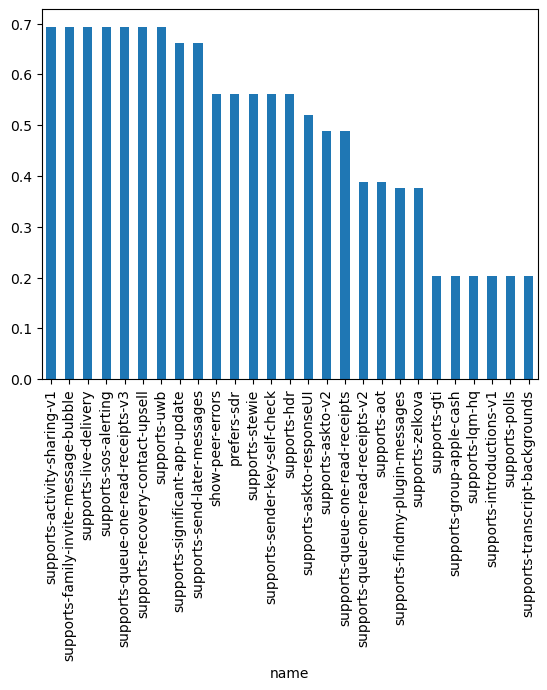

In [42]:
mi_scores2.plot(kind="bar")

In [43]:
top = mi_scores2.head(40).index

print(X_str2[top].T)

device_type                                    Mac                 VisionPro  \
device_model                          UniversalMac                 VisionPro   
os_version                              (15, 7, 3)      (26, 2)      (26, 0)   
name                                                                           
supports-activity-sharing-v1           <<MISSING>>  <<MISSING>>  <<MISSING>>   
supports-family-invite-message-bubble  <<MISSING>>  <<MISSING>>         True   
supports-live-delivery                 <<MISSING>>  <<MISSING>>         True   
supports-sos-alerting                  <<MISSING>>  <<MISSING>>  <<MISSING>>   
supports-queue-one-read-receipts-v3    <<MISSING>>  <<MISSING>>  <<MISSING>>   
supports-recovery-contact-upsell       <<MISSING>>  <<MISSING>>         True   
supports-uwb                           <<MISSING>>  <<MISSING>>  <<MISSING>>   
supports-significant-app-update        <<MISSING>>  <<MISSING>>  <<MISSING>>   
supports-send-later-messages            

In [44]:
X_top = X_raw2[top]
X_top.groupby(list(X_top.columns), dropna=False).apply(lambda df: df.index.tolist()).tolist()

/tmp/ipykernel_1004500/2589820200.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  X_top.groupby(list(X_top.columns), dropna=False).apply(lambda df: df.index.tolist()).tolist()


[[('Mac', 'UniversalMac', (15, 7, 3))],
 [('Mac', 'UniversalMac', (26, 2))],
 [('VisionPro', 'VisionPro', (26, 0))],
 [('iPad', 'iPad_Spring_2022', (26, 2))],
 [('Watch', 'Watch8,1', (26, 1))],
 [('Watch', 'Watch7,1', (26, 2))],
 [('iPhone', 'iPhone17,1', (26, 2)), ('iPhone', 'iPhone18,1', (26, 2))]]

In [45]:
def find_pure_rules(X, y):
    rules = []
    for col in X.columns:
        groups = X.groupby(col).groups
        for val, idx_labels in groups.items():
            labels_in_group = y.loc[idx_labels]
            counts = Counter(labels_in_group.tolist())
            if len(counts) == 1:
                predicted_type = next(iter(counts.keys()))
                coverage = len(labels_in_group)
                
                rules.append({
                    "flag": col,
                    "value": val,
                    "device_type": predicted_type,
                    "coverage": coverage,
                })
    return sorted(rules, key=lambda r: (-r["coverage"], r["flag"]))

In [46]:
dl_X = caps_pivot.astype("string").fillna("<<MISSING>>")
dl_X

name                                    ec-version kt-version  \
device_type device_model     os_version                         
Mac         UniversalMac     (15, 7, 3)        1.0        5.0   
                             (26, 2)           1.0        5.0   
VisionPro   VisionPro        (26, 0)           1.0        5.0   
Watch       Watch7,1         (26, 2)           1.0        5.0   
            Watch8,1         (26, 1)           1.0        5.0   
iPad        iPad_Spring_2022 (26, 2)           1.0        5.0   
iPhone      iPhone17,1       (26, 2)           1.0        5.0   
            iPhone18,1       (26, 2)           1.0        5.0   

name                                    nicknames-version  \
device_type device_model     os_version                     
Mac         UniversalMac     (15, 7, 3)               1.0   
                             (26, 2)                  1.0   
VisionPro   VisionPro        (26, 0)                  1.0   
Watch       Watch7,1         (26, 2)                  1.0   
            Watch8,1         (26, 1)                  1.0   
iPad        iPad_Spring_2022 (26, 2)                  1.0   
iPhone      iPhone17,1       (26, 2)                  1.0   
            iPhone18,1       (26, 2)                  1.0   

name                                    optionally-receive-typing-indicators  \
device_type device_model     os_version                                        
Mac         UniversalMac     (15, 7, 3)                                 True   
                             (26, 2)                                    True   
VisionPro   VisionPro        (26, 0)                                    True   
Watch       Watch7,1         (26, 2)                                    True   
            Watch8,1         (26, 1)                                    True   
iPad        iPad_Spring_2022 (26, 2)                                    True   
iPhone      iPhone17,1       (26, 2)                                    True   
            iPhone18,1       (26, 2)                                    True   

name                                    prefers-sdr  \
device_type device_model     os_version               
Mac         UniversalMac     (15, 7, 3)       False   
                             (26, 2)          False   
VisionPro   VisionPro        (26, 0)          False   
Watch       Watch7,1         (26, 2)            1.0   
            Watch8,1         (26, 1)            1.0   
iPad        iPad_Spring_2022 (26, 2)          False   
iPhone      iPhone17,1       (26, 2)          False   
            iPhone18,1       (26, 2)          False   

name                                    public-message-identity-ngm-version  \
device_type device_model     os_version                                       
Mac         UniversalMac     (15, 7, 3)                                13.0   
                             (26, 2)                                   13.0   
VisionPro   VisionPro        (26, 0)                                   13.0   
Watch       Watch7,1         (26, 2)                                   13.0   
            Watch8,1         (26, 1)                                   13.0   
iPad        iPad_Spring_2022 (26, 2)                                   13.0   
iPhone      iPhone17,1       (26, 2)                                   13.0   
            iPhone18,1       (26, 2)                                   13.0   

name                                    public-message-identity-version  \
device_type device_model     os_version                                   
Mac         UniversalMac     (15, 7, 3)                             2.0   
                             (26, 2)                                2.0   
VisionPro   VisionPro        (26, 0)                                2.0   
Watch       Watch7,1         (26, 2)                                2.0   
            Watch8,1         (26, 1)                                2.0   
iPad        iPad_Spring_2022 (26, 2)                                2.

In [47]:
dl_y = pd.Series(caps_pivot.index.get_level_values("device_type"), index=caps_pivot.index, name="device_type")
dl_y

device_type  device_model      os_version
Mac          UniversalMac      (15, 7, 3)          Mac
                               (26, 2)             Mac
VisionPro    VisionPro         (26, 0)       VisionPro
Watch        Watch7,1          (26, 2)           Watch
             Watch8,1          (26, 1)           Watch
iPad         iPad_Spring_2022  (26, 2)            iPad
iPhone       iPhone17,1        (26, 2)          iPhone
             iPhone18,1        (26, 2)          iPhone
Name: device_type, dtype: object

In [48]:
find_pure_rules(dl_X, dl_y)

[{'flag': 'prefers-sdr',
  'value': '1.0',
  'device_type': 'Watch',
  'coverage': 2},
 {'flag': 'show-peer-errors',
  'value': '<<MISSING>>',
  'device_type': 'Mac',
  'coverage': 2},
 {'flag': 'supports-hdr',
  'value': 'False',
  'device_type': 'Watch',
  'coverage': 2},
 {'flag': 'supports-sender-key-self-check',
  'value': '<<MISSING>>',
  'device_type': 'Mac',
  'coverage': 2},
 {'flag': 'supports-stewie',
  'value': 'True',
  'device_type': 'iPhone',
  'coverage': 2},
 {'flag': 'supports-findmy-plugin-messages',
  'value': '<<MISSING>>',
  'device_type': 'VisionPro',
  'coverage': 1},
 {'flag': 'supports-group-apple-cash',
  'value': '<<MISSING>>',
  'device_type': 'Mac',
  'coverage': 1},
 {'flag': 'supports-gti',
  'value': '<<MISSING>>',
  'device_type': 'Mac',
  'coverage': 1},
 {'flag': 'supports-introductions-v1',
  'value': '<<MISSING>>',
  'device_type': 'Mac',
  'coverage': 1},
 {'flag': 'supports-lqm-hq',
  'value': '<<MISSING>>',
  'device_type': 'Mac',
  'coverage': 

In [49]:
def greedy_decision_list(X, y):
    remaining = X.index
    decision_list = []

    while len(set(y.loc[remaining])) > 1:
        Xr = X.loc[remaining]
        yr = y.loc[remaining]

        rules = find_pure_rules(Xr, yr)
        
        if not rules:
            break

        best = rules[0]
        flag, value, dt = best["flag"], best["value"], best["device_type"]

        covered = Xr.index[Xr[flag] == value]
        decision_list.append((flag, value, dt, len(covered), rules))

        remaining = remaining.difference(covered)

    # -- stall detection --
    remaining_types = set(y.loc[remaining]) if len(remaining) else set()
    stalled = (len(remaining) > 0) and (len(remaining_types) > 1)

    # -- default rule --
    if len(remaining) > 0:
        default_type = y.loc[remaining].mode().iloc[0]
        default_coverage = len(remaining)
        default_correct = int((y.loc[remaining] == default_type).sum())
        default_accuracy = default_correct / default_coverage
    else:
        default_type = y.mode().iloc[0]
        default_coverage = 0
        default_correct = 0
        default_accuracy = None
    # default = y.loc[remaining].mode().iloc[0] if len(remaining) else y.mode().iloc[0]

    diagnostics = {
        "stalled": stalled,
        "remaining_samples": len(remaining),
        "remaining_types": remaining_types,
        "default_coverage": default_coverage,
        "default_accuracy_on_remaining": default_accuracy,
    }
    
    return decision_list, default_type, diagnostics

In [50]:
dl, default, diag = greedy_decision_list(dl_X, dl_y)

# dl, default, diag

In [51]:
for i, (flag, value, dt, cov, _) in enumerate(dl, 1):
    print(f"{"ELSE " if i > 1 else ""}IF {flag} == {value} -> {dt} (covers {cov})")
print(f"ELSE -> {default}")

IF prefers-sdr == 1.0 -> Watch (covers 2)
ELSE IF show-peer-errors == <<MISSING>> -> Mac (covers 2)
ELSE IF supports-activity-sharing-v1 == True -> iPhone (covers 2)
ELSE IF supports-aot == <<MISSING>> -> VisionPro (covers 1)
ELSE -> iPad


In [52]:
def format_cond(flag, value, cov, neg=False):
    op = "!=" if neg else "=="
    return f"{flag} {op} {value} ({cov})"

def format_conjunction(conds):
    return " AND ".join(conds) if conds else "<TRUE>"

def print_conjunction_rules(decision_list):
    prior_neg = []

    for step, (chosen_flag, chosen_value, chosen_dt, cov, rules) in enumerate(decision_list, 1):
        print(f"Step {step}")
        print(f"Chosen rule: IF {chosen_flag} == {chosen_value} -> {chosen_dt}")

        print("Alternatives")

        for r in rules:
            conds = []

            conds.append(format_cond(r["flag"], r["value"], r["coverage"]))

            conj = format_conjunction(conds)

            print(f"   IF {conj} -> {r['device_type']}")

In [53]:
print_conjunction_rules(dl)

Step 1
Chosen rule: IF prefers-sdr == 1.0 -> Watch
Alternatives
   IF prefers-sdr == 1.0 (2) -> Watch
   IF show-peer-errors == <<MISSING>> (2) -> Mac
   IF supports-hdr == False (2) -> Watch
   IF supports-sender-key-self-check == <<MISSING>> (2) -> Mac
   IF supports-stewie == True (2) -> iPhone
   IF supports-findmy-plugin-messages == <<MISSING>> (1) -> VisionPro
   IF supports-group-apple-cash == <<MISSING>> (1) -> Mac
   IF supports-gti == <<MISSING>> (1) -> Mac
   IF supports-introductions-v1 == <<MISSING>> (1) -> Mac
   IF supports-lqm-hq == <<MISSING>> (1) -> Mac
   IF supports-polls == <<MISSING>> (1) -> Mac
   IF supports-transcript-backgrounds == <<MISSING>> (1) -> Mac
   IF supports-zelkova == <<MISSING>> (1) -> VisionPro
Step 2
Chosen rule: IF show-peer-errors == <<MISSING>> -> Mac
Alternatives
   IF show-peer-errors == <<MISSING>> (2) -> Mac
   IF supports-activity-sharing-v1 == True (2) -> iPhone
   IF supports-family-invite-message-bubble == <<MISSING>> (2) -> Mac
   IF

In [54]:
(X_str.nunique(dropna=False) > 1).sum()

np.int64(27)